# 04 — Training

Train the transformer on increasing sample sizes from the Gambler's Ruin dataset.
For each training size N, fit a fresh model and save the best-validation (MAP)
checkpoint to `sample_size_models/`. Plot training and validation error against
sample size. Downstream Hessian / curvature analysis of these MAPs lives in
`05_analysis.ipynb`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm

/Users/ashrafahmed/code/slt-deep/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


# Resolve project root and add project-local packages/ to sys.path.
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root

if project_root is None:
    raise RuntimeError(
        "Could not locate markov-chain-learning project root from current working directory"
    )

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from pytorch_models import MarkovTransformer

## Configuration

In [3]:
# -- Papermill parameters -----------------------------------------------------
DATA_DIR = str(project_root / "experiments" / "single-chain" / "data")
DATA_DIR = Path(DATA_DIR)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [4]:
# -- Post-papermill coercions -------------------------------------------------
# Training
BATCH_SIZE = 256  # 256
EPOCHS = 100
LR = 3e-3
VAL_SPLIT = 0.1
SEED = 42
# Sample sizes to sweep; any values larger than the dataset will be skipped.
# Log-spaced from 50 up to the 3000-seq max.
N_GRID = [50, 80, 130, 200, 320, 520, 840, 1350, 2150, 3000]

EPOCHS = int(EPOCHS)
BATCH_SIZE = int(BATCH_SIZE)
SEED = int(SEED)
N_GRID = [int(n) for n in N_GRID]

torch.manual_seed(SEED)

## Load data

In [5]:
class MarkovSequenceDataset(Dataset):
    def __init__(self, sequences: torch.Tensor):
        self.data = sequences

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
sequences = data["sequences"]
Ts = data["Ts"]
pis = data["pis"]

data_cfg = data.get("config")
if not isinstance(data_cfg, dict):
    raise KeyError("Dataset is missing required metadata: data['config']")

required_keys = ("n_states", "L")
missing_keys = [k for k in required_keys if k not in data_cfg]
if missing_keys:
    raise KeyError(
        f"Dataset config missing required keys: {missing_keys}. "
        "Regenerate the dataset with 02_dataset.ipynb."
    )

try:
    VOCAB_SIZE = int(data_cfg["n_states"])
    MAX_LEN = int(data_cfg["L"])
except (TypeError, ValueError) as exc:
    raise ValueError(
        "Dataset config keys 'n_states' and 'L' must be integer-like values."
    ) from exc

if VOCAB_SIZE <= 0 or MAX_LEN <= 0:
    raise ValueError(
        f"Dataset config has invalid dimensions: n_states={VOCAB_SIZE}, L={MAX_LEN}"
    )

if int(sequences.shape[1]) != MAX_LEN:
    raise ValueError(
        f"Dataset config mismatch: L={MAX_LEN} but sequences.shape[1]={sequences.shape[1]}"
    )

PAD_ID = int(data_cfg.get("pad_id", -1))
DGP_REGIME = data_cfg.get("dgp_regime", "unknown")

print(f"DGP regime  : {DGP_REGIME}")
print(f"Loaded {len(sequences)} sequences, shape {tuple(sequences.shape)}")
print(
    f"PAD_ID={PAD_ID}, Ts shape: {tuple(Ts.shape)}, VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}"
)

full_ds = MarkovSequenceDataset(sequences)
n_val = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(
    full_ds,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {n_train}   Val: {n_val}")

DGP regime  : single
Loaded 3000 sequences, shape (3000, 10)
PAD_ID=-1, Ts shape: (1, 5, 5), VOCAB_SIZE=5, MAX_LEN=10
Train: 2700   Val: 300


## Training loop

In [6]:
device = torch.device("cpu")
print("Device:", device)

D_MODEL = VOCAB_SIZE * 2
model = MarkovTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    max_len=MAX_LEN,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
print(model)

Device: cpu
MarkovTransformer(
  (input_proj): Linear(in_features=5, out_features=10, bias=False)
  (rel_pos_bias): Embedding(10, 1)
  (layers): ModuleList(
    (0-1): 2 x Attention(
      (W_q): Linear(in_features=10, out_features=10, bias=False)
      (W_k): Linear(in_features=10, out_features=10, bias=False)
      (W_v): Linear(in_features=10, out_features=10, bias=False)
      (W_o): Linear(in_features=10, out_features=10, bias=False)
    )
  )
  (head): Linear(in_features=10, out_features=5, bias=False)
)


In [7]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")

# Per-module breakdown
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:<20} {n:>6,} params")

Total parameters    : 910
Trainable parameters: 910
  input_proj               50 params
  rel_pos_bias             10 params
  layers                  800 params
  head                     50 params


In [8]:
def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, n_tokens = 0.0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(device)
            x_in = batch[:, :-1]
            x_tgt = batch[:, 1:]
            # Replace PAD_ID with 0 for one_hot encoding (loss ignores these positions)
            x_in = x_in.clone()
            x_in[x_in == PAD_ID] = 0
            logits = model(x_in)
            _, _, vocab_dim = logits.shape
            loss = criterion(logits.reshape(-1, vocab_dim), x_tgt.reshape(-1))

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            valid_tokens = (x_tgt != PAD_ID).sum().item()
            total_loss += loss.item() * valid_tokens
            n_tokens += valid_tokens

    return total_loss / max(n_tokens, 1)


sample_size_models_dir = DATA_DIR / "sample_size_models"
sample_size_models_dir.mkdir(parents=True, exist_ok=True)

# Minimum validation sequences so small-N val loss is not pure noise
# (e.g. int(32 * 0.1) = 3 sequences gives ~27 tokens). Floor it.
MIN_VAL = 8

sample_size_records = []

for N in N_GRID:
    if len(full_ds) < N:
        print(
            f"Skipping sample size N={N} because dataset has only {len(full_ds)} sequences."
        )
        continue

    rng = torch.Generator().manual_seed(SEED + N)
    indices = torch.randperm(len(full_ds), generator=rng)[:N].tolist()
    subset_ds = torch.utils.data.Subset(full_ds, indices)

    n_val = max(int(len(subset_ds) * VAL_SPLIT), min(MIN_VAL, len(subset_ds) - 1))
    n_train = len(subset_ds) - n_val
    train_ds, val_ds = random_split(
        subset_ds,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED + N),
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    print(f"=== Training sample size N={N} (train={n_train}, val={n_val}) ===")

    model = MarkovTransformer(
        vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        max_len=MAX_LEN,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

    train_losses, val_losses, grad_norms = [], [], []
    best_val_loss = float("inf")
    # Train loss at the best-val epoch (the checkpoint we actually keep).
    train_loss_at_best = float("nan")
    best_epoch = None

    for epoch in tqdm(range(1, EPOCHS + 1), desc=f"Training N={N}"):
        tr_loss = run_epoch(train_loader, training=True)
        val_loss = run_epoch(val_loader, training=False)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        gnorm = (
            sum(
                p.grad.norm().item() ** 2
                for p in model.parameters()
                if p.grad is not None
            )
            ** 0.5
        )
        grad_norms.append(gnorm)

        # Keep only the best-val checkpoint per sample size — that is the model
        # used for all downstream Hessian / sample-size analysis. We do not
        # persist per-epoch checkpoints (no during-training curvature analysis).
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            train_loss_at_best = tr_loss
            best_epoch = epoch
            best_checkpoint = {
                "model_state": model.state_dict(),
                "config": dict(vocab_size=VOCAB_SIZE, d_model=D_MODEL, max_len=MAX_LEN),
                "epoch": epoch,
                "train_loss": tr_loss,
                "val_loss": val_loss,
                "best_val_loss": best_val_loss,
                "training": {
                    "architecture": "pytorch_models.MarkovTransformer",
                    "dgp_regime": DGP_REGIME,
                    "sample_size": N,
                },
            }
            torch.save(
                best_checkpoint,
                sample_size_models_dir / f"checkpoint_N_{N}.pt",
            )

    torch.save(
        {
            "epochs": list(range(1, EPOCHS + 1)),
            "train_losses": train_losses,
            "val_losses": val_losses,
            "grad_norms": grad_norms,
        },
        DATA_DIR / f"training_history_N_{N}.pt",
    )

    sample_size_records.append(
        {
            "N": N,
            "final_train_loss": train_losses[-1],
            "final_val_loss": val_losses[-1],
            "best_val_loss": best_val_loss,
            "train_loss_at_best": train_loss_at_best,
            "best_epoch": best_epoch,
            "checkpoint_path": str(sample_size_models_dir / f"checkpoint_N_{N}.pt"),
            "n_train": n_train,
            "n_val": n_val,
        }
    )

    print(
        f"Finished N={N}: final_train={train_losses[-1]:.4f}, final_val={val_losses[-1]:.4f}, "
        f"best_val={best_val_loss:.4f} @epoch {best_epoch} -> {sample_size_models_dir / f'checkpoint_N_{N}.pt'}"
    )

torch.save(sample_size_records, DATA_DIR / "sample_size_sweep.pt")
print(f"Saved sample-size sweep metadata to: {DATA_DIR / 'sample_size_sweep.pt'}")

=== Training sample size N=50 (train=42, val=8) ===


Training N=50: 100%|██████████| 100/100 [00:00<00:00, 349.24it/s]


Finished N=50: final_train=1.2084, final_val=1.5869, best_val=1.5000 @epoch 53 -> /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/sample_size_models/checkpoint_N_50.pt
=== Training sample size N=80 (train=72, val=8) ===


Training N=80: 100%|██████████| 100/100 [00:00<00:00, 411.73it/s]


Finished N=80: final_train=1.2016, final_val=1.4875, best_val=1.4577 @epoch 5 -> /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/sample_size_models/checkpoint_N_80.pt
=== Training sample size N=130 (train=117, val=13) ===


...

Finished N=1350: final_train=1.2575, final_val=1.2333, best_val=1.2313 @epoch 83 -> /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/sample_size_models/checkpoint_N_1350.pt
=== Training sample size N=2150 (train=1935, val=215) ===


Training N=2150: 100%|██████████| 100/100 [00:03<00:00, 26.41it/s]


Finished N=2150: final_train=1.2435, final_val=1.3048, best_val=1.3034 @epoch 83 -> /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/sample_size_models/checkpoint_N_2150.pt
=== Training sample size N=3000 (train=2700, val=300) ===


Training N=3000: 100%|██████████| 100/100 [00:05<00:00, 18.93it/s]

Finished N=3000: final_train=1.2536, final_val=1.2450, best_val=1.2418 @epoch 59 -> /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/sample_size_models/checkpoint_N_3000.pt
Saved sample-size sweep metadata to: /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/sample_size_sweep.pt


## Loss vs sample size

Plot the final train and validation losses for each sample size in the sweep.
This shows how the per-token error changes as the amount of training data grows,
instead of following loss vs epoch for a single run.


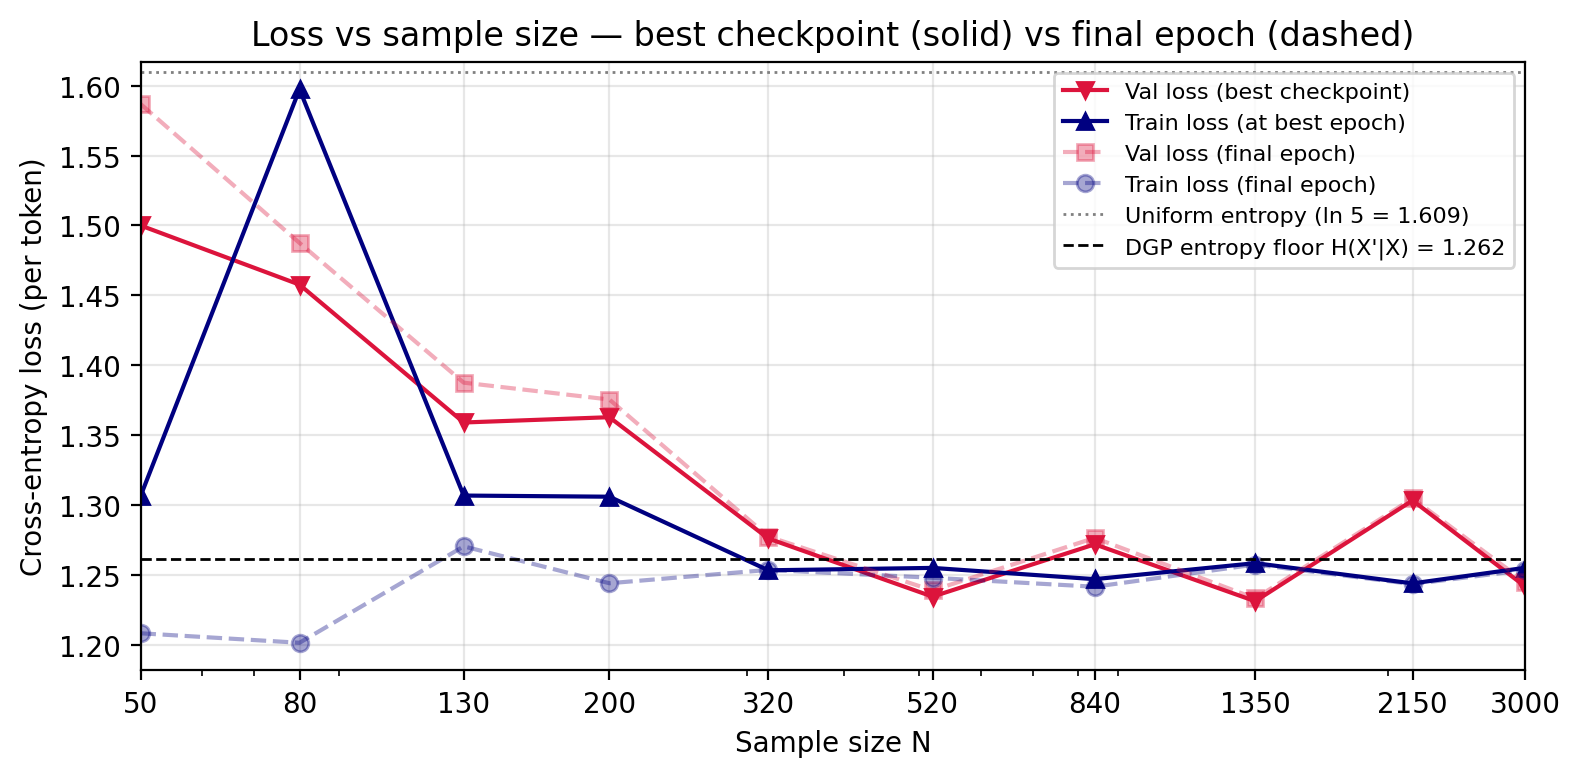

In [9]:
import math

sample_sizes = [rec["N"] for rec in sample_size_records]
final_train_losses_n = [rec["final_train_loss"] for rec in sample_size_records]
final_val_losses_n = [rec["final_val_loss"] for rec in sample_size_records]
best_val_losses_n = [rec["best_val_loss"] for rec in sample_size_records]
# Train loss measured at the same epoch as the best-val checkpoint.
train_at_best_n = [rec["train_loss_at_best"] for rec in sample_size_records]

uniform_entropy = math.log(VOCAB_SIZE)  # per-token CE of a uniform predictor
T_ref, pi_ref = Ts[0], pis[0]
logT = torch.log(T_ref.clamp_min(1e-12))
cond_entropy = float(-(pi_ref[:, None] * T_ref * logT).sum().item())

# --- Loss vs sample size: best-val checkpoint (primary) vs final epoch (reference) ---
# NOTE: the (val − train) gap is NOT a meaningful generalization quantity in the
# singular setting; the principled generalization-error estimate (leave-one-out)
# is computed and plotted in the next section.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    sample_sizes,
    best_val_losses_n,
    marker="v",
    color="crimson",
    label="Val loss (best checkpoint)",
)
ax.plot(
    sample_sizes,
    train_at_best_n,
    marker="^",
    color="navy",
    label="Train loss (at best epoch)",
)
# Reference: final-epoch values, faint dashed, to expose overfitting at small N.
ax.plot(
    sample_sizes,
    final_val_losses_n,
    marker="s",
    color="crimson",
    alpha=0.35,
    ls="--",
    label="Val loss (final epoch)",
)
ax.plot(
    sample_sizes,
    final_train_losses_n,
    marker="o",
    color="navy",
    alpha=0.35,
    ls="--",
    label="Train loss (final epoch)",
)
ax.axhline(
    uniform_entropy,
    color="gray",
    lw=1.0,
    ls=":",
    label=f"Uniform entropy (ln {VOCAB_SIZE} = {uniform_entropy:.3f})",
)
ax.axhline(
    cond_entropy,
    color="black",
    lw=1.0,
    ls="--",
    label=f"DGP entropy floor H(X'|X) = {cond_entropy:.3f}",
)
ax.set_xscale("log")
ax.set_xlim(min(sample_sizes), max(sample_sizes))
ax.set_xticks(sample_sizes)
ax.set_xticklabels([str(n) for n in sample_sizes])
ax.set_xlabel("Sample size N")
ax.set_ylabel("Cross-entropy loss (per token)")
ax.set_title("Loss vs sample size — best checkpoint (solid) vs final epoch (dashed)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Cross-validation generalization error vs sample size

In the singular-learning setting the (val − train) gap is not a meaningful
generalization quantity. The principled estimator is **cross-validation error**.
Exact leave-one-out (LOO) is the gold standard but costs ≈ Σ N ≈ 9,300 from-scratch
fits. Instead we use **K-fold CV with an adaptive fold size**, `fold = max(10, N//20)`:
partition each N-sequence subset into disjoint folds, and for each fold refit the
model from scratch on the remaining sequences and evaluate per-token NLL on the
held-out fold. Every sequence is held out exactly once; the CV error is the
token-weighted mean held-out NLL over all folds.

The adaptive size keeps the held-out chunk modest at small N (10 at N=250) and scales
it up at large N (≈150 at N=3000), so the number of refits per N stays ~18–25. This
is a well-established fast approximation to LOO and a far better generalization
estimate than the train/val gap.

Guarded by `RUN_CV` (default **False**); result cached to `cv_error_per_N.pt`. Each
fold trains from scratch for the full `EPOCHS`. Set `RUN_CV = True` to compute; the
plot loads from cache when present.


In [10]:
# ── K-fold cross-validation generalization error per sample size ──
# Adaptive fold size per N: fold = max(10, N // 20). Keeps the held-out chunk
# modest at small N and scales it up at large N, so fold count stays ~18-25.
# Guarded: ~Σ ceil(N/fold) ≈ a few hundred from-scratch fits.
RUN_CV = True
CV_PATH = DATA_DIR / "cv_error_per_N.pt"


def fold_size_for(N):
    return max(10, N // 20)


def fit_per_token_nll(train_seqs, eval_seqs, *, epochs=EPOCHS, seed=SEED):
    """Train a fresh MarkovTransformer on train_seqs (same recipe as the main loop)
    and return (mean per-token NLL on eval_seqs, n_valid_tokens). Both are
    (n, MAX_LEN) tensors; eval_seqs may hold multiple held-out sequences."""
    torch.manual_seed(seed)
    m = MarkovTransformer(vocab_size=VOCAB_SIZE, d_model=D_MODEL, max_len=MAX_LEN).to(
        device
    )
    opt = torch.optim.Adam(m.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss(ignore_index=PAD_ID)

    def batches(seqs):
        for s in range(0, len(seqs), BATCH_SIZE):
            yield seqs[s : s + BATCH_SIZE]

    m.train(True)
    for _ in range(epochs):
        for batch in batches(train_seqs):
            x_in = batch[:, :-1].clone()
            x_tgt = batch[:, 1:]
            x_in[x_in == PAD_ID] = 0
            logits = m(x_in)
            loss = crit(logits.reshape(-1, logits.shape[-1]), x_tgt.reshape(-1))
            opt.zero_grad()
            loss.backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        x_in = eval_seqs[:, :-1].clone()
        x_tgt = eval_seqs[:, 1:]
        x_in[x_in == PAD_ID] = 0
        logits = m(x_in)
        ce = nn.functional.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            x_tgt.reshape(-1),
            reduction="none",
            ignore_index=PAD_ID,
        )
        mask = (x_tgt.reshape(-1) != PAD_ID).float()
        n_tok = float(mask.sum())
        return float((ce * mask).sum() / max(n_tok, 1.0)), n_tok


if RUN_CV:
    total_fits = sum(
        (min(N, len(full_ds)) + fold_size_for(N) - 1) // fold_size_for(N)
        for N in N_GRID
    )
    print(
        f"K-fold CV (adaptive fold = max(10, N//20)): {total_fits} from-scratch fits "
        f"across N_GRID={N_GRID}."
    )

    cv_records = []
    for N in N_GRID:
        if len(full_ds) < N:
            continue
        fold = fold_size_for(N)
        # Reuse the EXACT subset the trained MLE for this N used.
        rng = torch.Generator().manual_seed(SEED + N)
        idx = torch.randperm(len(full_ds), generator=rng)[:N].tolist()
        subset = sequences[idx]  # (N, MAX_LEN)

        # Disjoint folds over a fixed shuffle (last fold may be smaller).
        fold_perm = torch.randperm(N, generator=torch.Generator().manual_seed(SEED + N))
        fold_starts = list(range(0, N, fold))

        fold_nlls, fold_tokens = [], []
        for start in tqdm(fold_starts, desc=f"CV N={N} (fold={fold})"):
            test_pos = fold_perm[start : start + fold]
            mask = torch.ones(N, dtype=torch.bool)
            mask[test_pos] = False
            nll, n_tok = fit_per_token_nll(
                subset[mask], subset[test_pos], seed=SEED + N
            )
            fold_nlls.append(nll)
            fold_tokens.append(n_tok)

        fold_nlls_t = torch.tensor(fold_nlls)
        fold_tokens_t = torch.tensor(fold_tokens)
        # Token-weighted mean across folds = held-out per-token NLL over all N sequences.
        cv_err = float((fold_nlls_t * fold_tokens_t).sum() / fold_tokens_t.sum())
        cv_std = float(fold_nlls_t.std())  # spread across folds
        cv_records.append(
            {
                "N": N,
                "cv_error": cv_err,
                "cv_std": cv_std,
                "n_folds": len(fold_nlls),
                "fold_size": fold,
            }
        )
        print(
            f"  N={N}: CV error = {cv_err:.4f} (±{cv_std:.4f} across "
            f"{len(fold_nlls)} folds of {fold})"
        )

    torch.save(cv_records, CV_PATH)
    print(f"Saved K-fold CV results to {CV_PATH}")
else:
    print(
        f"RUN_CV is False — skipping the K-fold CV computation. "
        f"Set RUN_CV=True to compute. Plot below uses cache if {CV_PATH.name} exists."
    )

K-fold CV (adaptive fold = max(10, N//20)): 168 from-scratch fits across N_GRID=[50, 80, 130, 200, 320, 520, 840, 1350, 2150, 3000].


CV N=50 (fold=10): 100%|██████████| 5/5 [00:00<00:00,  7.03it/s]


  N=50: CV error = 1.4704 (±0.1198 across 5 folds of 10)


CV N=80 (fold=10): 100%|██████████| 8/8 [00:01<00:00,  5.48it/s]


  N=80: CV error = 1.3298 (±0.2393 across 8 folds of 10)


...

  N=1350: CV error = 1.3028 (±0.0588 across 21 folds of 67)


CV N=2150 (fold=107): 100%|██████████| 21/21 [01:14<00:00,  3.54s/it]


  N=2150: CV error = 1.2544 (±0.0472 across 21 folds of 107)


CV N=3000 (fold=150): 100%|██████████| 20/20 [01:39<00:00,  4.99s/it]

  N=3000: CV error = 1.2597 (±0.0338 across 20 folds of 150)
Saved K-fold CV results to /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/cv_error_per_N.pt


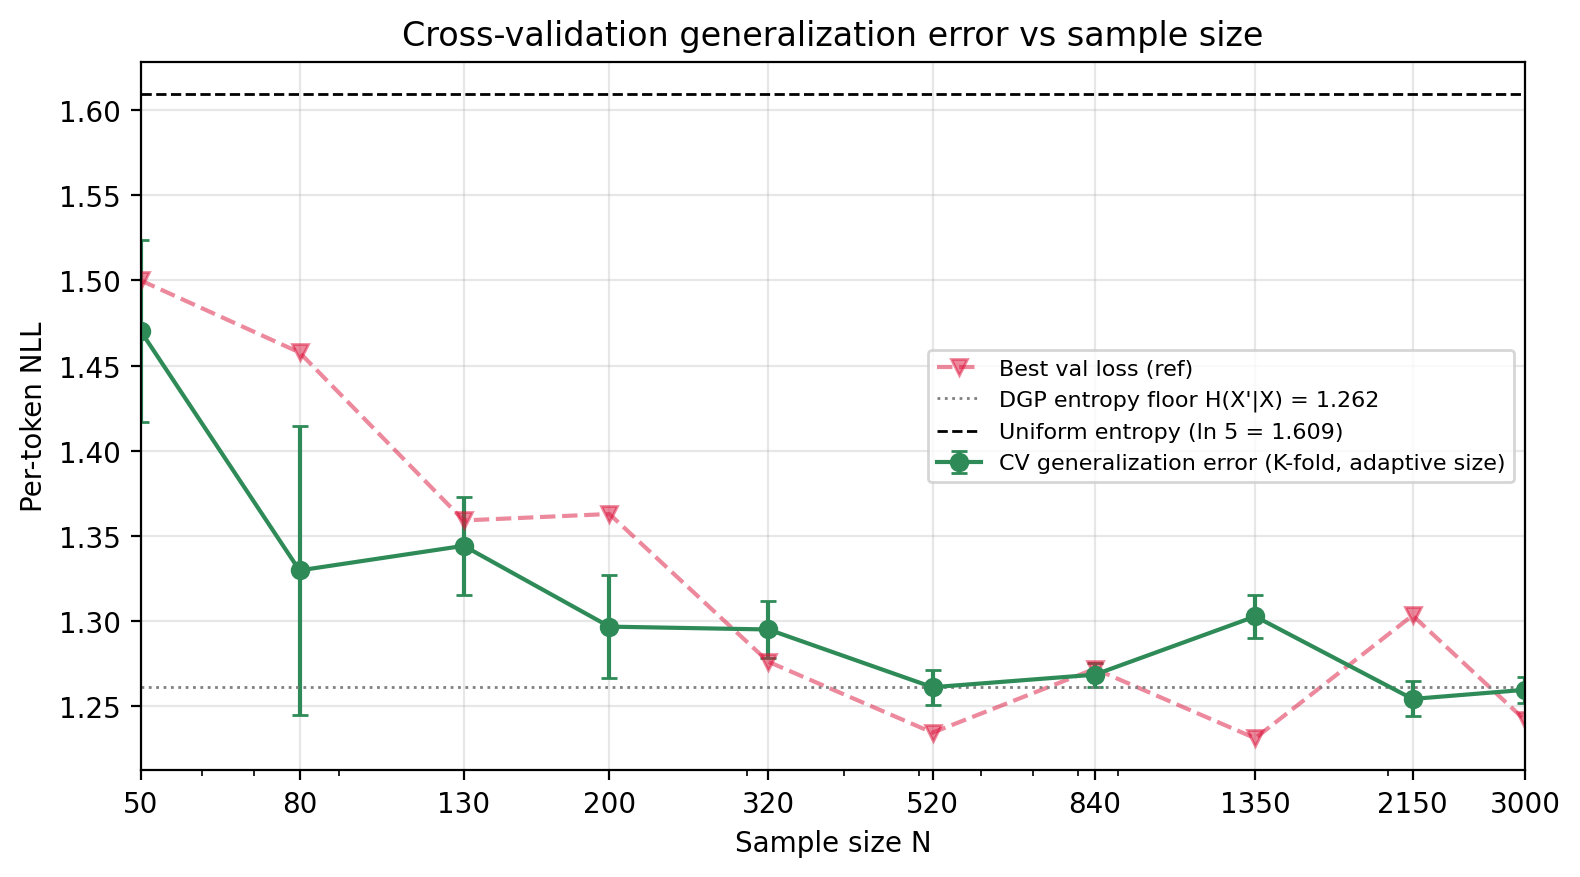

  N=   50: CV=1.4704  (5 folds of 10)
  N=   80: CV=1.3298  (8 folds of 10)
  N=  130: CV=1.3442  (13 folds of 10)
  N=  200: CV=1.2968  (20 folds of 10)
  N=  320: CV=1.2951  (20 folds of 16)
  N=  520: CV=1.2612  (20 folds of 26)
  N=  840: CV=1.2686  (20 folds of 42)
  N= 1350: CV=1.3028  (21 folds of 67)
  N= 2150: CV=1.2544  (21 folds of 107)
  N= 3000: CV=1.2597  (20 folds of 150)


In [12]:
# ── Plot: K-fold cross-validation generalization error vs sample size ──
if CV_PATH.exists():
    cv_records = sorted(torch.load(CV_PATH, weights_only=False), key=lambda r: r["N"])
    cv_N = [r["N"] for r in cv_records]
    cv_err = [r["cv_error"] for r in cv_records]
    # Standard error of the CV mean: spread across folds / sqrt(n_folds).
    cv_se = [r["cv_std"] / max(r["n_folds"], 1) ** 0.5 for r in cv_records]

    # DGP conditional-entropy floor H(X'|X): irreducible per-token NLL.
    T_ref, pi_ref = Ts[0], pis[0]
    logT = torch.log(T_ref.clamp_min(1e-12))
    cond_entropy = float(-(pi_ref[:, None] * T_ref * logT).sum().item())
    uniform_entropy = math.log(VOCAB_SIZE)  # per-token CE of a uniform predictor

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.errorbar(
        cv_N,
        cv_err,
        yerr=cv_se,
        marker="o",
        color="seagreen",
        capsize=3,
        label="CV generalization error (K-fold, adaptive size)",
    )
    # Best-val loss overlaid for context (NOT the same quantity).
    by_N = {rec["N"]: rec["best_val_loss"] for rec in sample_size_records}
    ax.plot(
        [n for n in cv_N if n in by_N],
        [by_N[n] for n in cv_N if n in by_N],
        marker="v",
        color="crimson",
        alpha=0.5,
        ls="--",
        label="Best val loss (ref)",
    )
    ax.axhline(
        cond_entropy,
        color="gray",
        ls=":",
        lw=1.0,
        label=f"DGP entropy floor H(X'|X) = {cond_entropy:.3f}",
    )
    ax.axhline(
        uniform_entropy,
        color="black",
        lw=1.0,
        ls="--",
        label=f"Uniform entropy (ln {VOCAB_SIZE} = {uniform_entropy:.3f})",
    )
    ax.set_xscale("log")
    ax.set_xlim(min(cv_N), max(cv_N))
    ax.set_xticks(cv_N)
    ax.set_xticklabels([str(n) for n in cv_N])
    ax.set_xlabel("Sample size N")
    ax.set_ylabel("Per-token NLL")
    ax.set_title("Cross-validation generalization error vs sample size")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    for r in cv_records:
        print(
            f"  N={r['N']:5d}: CV={r['cv_error']:.4f}  "
            f"({r['n_folds']} folds of {r['fold_size']})"
        )
else:
    print(f"No CV cache at {CV_PATH} — run the cell above with RUN_CV=True first.")